In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('../artifacts/row.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(2772, 7)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(1337, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

In [9]:
print('Quantile 1', Q1)
print('Quantile 3', Q3)
print('IQR ', IQR)

Quantile 1 4746.344
Quantile 3 16657.71745
IQR  11911.37345


In [48]:
new_df = df[(df['charges'] >= Q1 - 1.5 * IQR) & (df['charges'] <= Q3 + 1.5 * IQR)]

In [22]:
new_df.shape

(1198, 7)

Text(0.5, 0, 'Charges')

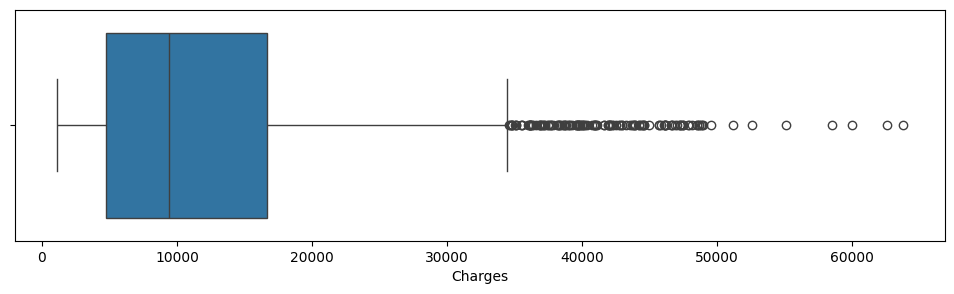

In [ ]:
plt.figure(figsize=(12,3))
sns.boxplot(data=df  , x=df['charges'])
plt.xlabel('Charges')

Text(0.5, 0, 'Charges')

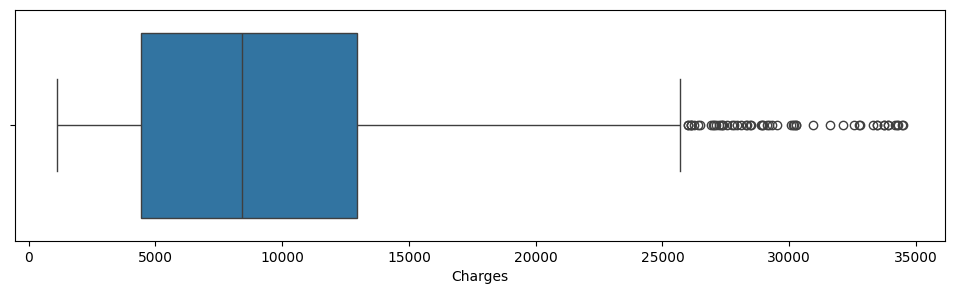

In [24]:

plt.figure(figsize=(12,3))
sns.boxplot(data=new_df  , x=new_df['charges'])
plt.xlabel('Charges')

In [47]:
new_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [49]:
new_df = pd.get_dummies(new_df , drop_first=True, dtype=int)

In [50]:
new_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [58]:
new_df.to_csv('../artifacts/clean_data.csv')